# 🎧 Tema 3 — Spotify: características de áudio entre gêneros musicais

**Entidade:** Insper Data — Ciclo Básico · Projeto 1
**Base:** *Spotify Tracks Dataset* (Kaggle — `maharshipandya`) · 114.000 faixas · 114 gêneros
**Autores:** *(preencher)*

---

### Pergunta-guia

> **Como as características de áudio diferem entre dois gêneros musicais distintos, usando gráficos de densidade (KDE)?**

Para responder, o notebook segue quatro perguntas, na ordem:

1. **Quais dois gêneros comparar** — e com que critério essa escolha foi feita?
2. Quais características de áudio têm as distribuições **mais separadas** entre os dois gêneros?
3. Existe alguma característica que **praticamente se sobrepõe**, ou seja, que não ajuda a diferenciar?
4. A **popularidade** varia entre os dois gêneros? Isso parece ter relação com o áudio?

O roteiro da apresentação de 5 minutos está na **seção 9**, no final.

## 0. Preparação

Antes de qualquer coisa: bibliotecas, configuração de exibição e uma paleta fixa. Os dois gêneros
terão **sempre a mesma cor** em todos os gráficos — quem assiste à apresentação não deveria precisar
reaprender a legenda a cada slide.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Exibição: mostrar todas as colunas da base sem quebrar linha.
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Estilo dos gráficos. Uma cor por gênero, do começo ao fim do notebook.
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['font.size'] = 10

CORES = {'rock': '#2E86AB', 'reggaeton': '#F18F01'}
PAR = ['rock', 'reggaeton']

print('Tudo pronto. pandas', pd.__version__, '| seaborn', sns.__version__)

Tudo pronto. pandas 3.0.3 | seaborn 0.13.2


## 1. A base

### 1.1. Dicionário de variáveis

| Coluna | O que é |
|---|---|
| `track_id`, `artists`, `album_name`, `track_name` | identificação da faixa |
| `track_genre` | gênero atribuído pelo Spotify (**114 valores**, 1.000 faixas cada) |
| `popularity` | 0 a 100, calculado pelo Spotify a partir de execuções recentes |
| `duration_ms` | duração em milissegundos |
| `explicit` | tem conteúdo explícito (True/False) |
| `danceability` | 0 a 1 — o quanto a faixa é "dançável" (ritmo estável, batida forte, regularidade) |
| `energy` | 0 a 1 — intensidade e atividade percebidas |
| `key`, `mode` | tom (0 = Dó … 11 = Si) e modo (0 = menor, 1 = maior) |
| `loudness` | volume médio em dB (negativo; quanto mais perto de 0, mais alto) |
| `speechiness` | 0 a 1 — presença de palavra falada/cantada em destaque |
| `acousticness` | 0 a 1 — confiança de que a faixa é acústica |
| `instrumentalness` | 0 a 1 — confiança de que **não** há vocal |
| `liveness` | 0 a 1 — indícios de plateia (gravação ao vivo) |
| `valence` | 0 a 1 — "positividade" musical (alegre × triste) |
| `tempo` | andamento estimado, em BPM |
| `time_signature` | fórmula de compasso estimada (nesta base: 1, 3, 4 ou 5 — e 0 quando falha) |

In [2]:
df_bruto = pd.read_csv('data/dataset.csv')

# A primeira coluna do CSV não tem nome: é só o índice salvo junto. Não serve para nada.
df_bruto = df_bruto.drop(columns=['Unnamed: 0'])

print('Formato da base:', df_bruto.shape)
df_bruto.head(5)

Formato da base: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
df_bruto.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

### 1.2. Que tipos de variáveis temos aqui? *(Aula 2)*

> **✅ Resposta**
>
> - **Qualitativas nominais:** `track_genre`, `artists`, `album_name`, `key` (o tom é um rótulo —
>   Ré não é "maior" que Dó), `mode` e `explicit` (binárias). `track_id` é identificador, não categoria.
> - **Qualitativas ordinais:** nenhuma clara. `popularity` tem ordem, mas é numérica com escala.
> - **Quantitativas discretas:** `time_signature`, `popularity` (inteiro de 0 a 100).
> - **Quantitativas contínuas:** `danceability`, `energy`, `loudness`, `speechiness`,
>   `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `duration_ms`.
>
> Essa separação não é burocracia: ela decide o gráfico. **KDE só faz sentido nas contínuas.**
> Fazer uma curva de densidade de `key` inventaria algo como "tom 4,3", que não existe (Aula 3).
> As nove variáveis contínuas de áudio são exatamente as candidatas da nossa pergunta-guia.

## 2. Diagnóstico e limpeza *(Aula 1)*

Antes de comparar qualquer coisa, precisamos saber **o quanto a base dói**. Quatro frentes:
valores faltantes, duplicatas, valores impossíveis e valores que *parecem* dados mas são ausência
disfarçada.

In [4]:
# --- Frente 1: valores faltantes ---
nulos = pd.DataFrame({
    'nulos': df_bruto.isna().sum(),
    '%': (df_bruto.isna().mean() * 100).round(3),
})
print(nulos[nulos['nulos'] > 0])

# Quem é a linha problemática?
df_bruto[df_bruto.isna().any(axis=1)]

            nulos      %
artists         1  0.001
album_name      1  0.001
track_name      1  0.001


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


> **✅ Leitura:** uma única linha (de 114.000) está sem `artists`, `album_name` e `track_name` —
> e ainda por cima tem `duration_ms = 0`. É um registro quebrado, não um padrão. Remover é seguro:
> perdemos 0,0009% da base.

In [5]:
# --- Frente 2: duplicatas ---
print('Linhas idênticas em tudo:          ', df_bruto.duplicated().sum())
print('track_id repetido na base inteira: ', df_bruto['track_id'].duplicated().sum())

# Cuidado: track_id repetido NÃO é necessariamente erro. A base foi montada
# pegando 1.000 faixas por gênero, e a mesma faixa pode ter sido sorteada em
# mais de um gênero (ex.: uma música que é 'pop' e 'dance' ao mesmo tempo).
generos_por_faixa = df_bruto.groupby('track_id')['track_genre'].nunique()
print('Faixas que aparecem em mais de um gênero:', (generos_por_faixa > 1).sum(),
      '| máximo de gêneros para uma mesma faixa:', generos_por_faixa.max())

Linhas idênticas em tudo:           450
track_id repetido na base inteira:  24259


Faixas que aparecem em mais de um gênero: 16299 | máximo de gêneros para uma mesma faixa: 9


> **✅ Decisão:** existem 24.259 `track_id` repetidos, mas **16.299 faixas aparecem legitimamente em
> mais de um gênero** — isso é o desenho da coleta, não sujeira. Se aplicássemos
> `drop_duplicates('track_id')` às cegas, destruiríamos o equilíbrio de 1.000 faixas por gênero e
> cada gênero ficaria com um tamanho diferente.
>
> A duplicata **real** é a mesma faixa repetida **dentro do mesmo gênero**: aí sim é a mesma
> observação contada duas vezes. São 450 casos, e é só esses que removemos.

In [6]:
print('Duplicatas reais (mesma faixa, mesmo gênero):',
      df_bruto.duplicated(subset=['track_id', 'track_genre']).sum())

Duplicatas reais (mesma faixa, mesmo gênero): 450


In [7]:
# --- Frente 3: valores impossíveis ---
print('duration_ms = 0 (faixa sem duração):    ', (df_bruto['duration_ms'] == 0).sum())
print('tempo = 0 BPM (andamento não detectado):', (df_bruto['tempo'] == 0).sum())
print('time_signature = 0 (compasso inválido): ', (df_bruto['time_signature'] == 0).sum())
print()
print('Duração máxima, em minutos:', round(df_bruto['duration_ms'].max() / 60000, 1))

duration_ms = 0 (faixa sem duração):     1
tempo = 0 BPM (andamento não detectado): 157
time_signature = 0 (compasso inválido):  163

Duração máxima, em minutos: 87.3


> **✅ Leitura:** 157 faixas com `tempo = 0` e 163 com `time_signature = 0` são **falhas do
> detector** do Spotify, não músicas paradas. Nenhuma música tem 0 BPM. Como são valores
> impossíveis e representam ~0,14% da base, viram `NaN` — assim eles somem das médias e dos
> gráficos sem que a linha inteira seja jogada fora.
>
> Já a faixa de 87 minutos **não** é erro: são gêneros como `sleep` e `ambient`, que têm faixas
> longas de verdade. Outlier não é sinônimo de erro (Aula 1) — esse a gente mantém.

In [8]:
# --- Frente 4: a ausência disfarçada de dado ---
# popularity = 0 é suspeito: é o valor que o Spotify devolve tanto para 'ninguém ouve'
# quanto para 'não consegui medir'. Se fosse de verdade impopularidade, os zeros estariam
# espalhados pela base. Vamos ver como eles se distribuem por gênero.
zeros = (df_bruto.groupby('track_genre')['popularity']
         .apply(lambda s: (s == 0).mean() * 100)
         .sort_values(ascending=False))

print('Zeros de popularity na base inteira: %.1f%%' % ((df_bruto['popularity'] == 0).mean() * 100))
print()
print('--- Gêneros com MAIS zeros (%) ---'); print(zeros.head(8).round(1))
print()
print('--- Gêneros com MENOS zeros (%) ---'); print(zeros.tail(6).round(1))

Zeros de popularity na base inteira: 14.1%

--- Gêneros com MAIS zeros (%) ---
track_genre
jazz       68.1
iranian    65.6
romance    63.6
soul       61.1
latin      58.8
country    58.7
rock       52.5
dance      49.0
Name: popularity, dtype: float64

--- Gêneros com MENOS zeros (%) ---
track_genre
detroit-techno    0.1
club              0.1
sertanejo         0.1
comedy            0.0
forro             0.0
honky-tonk        0.0
Name: popularity, dtype: float64


> **⚠️ Achado importante.** Os zeros não são aleatórios: **68% do `jazz` e 52% do `rock` têm
> popularidade 0**, contra praticamente **0% do `forro` e do `honky-tonk`**. Isso não é o mundo
> dizendo que ninguém ouve rock — é um artefato da coleta (faixa indisponível na região consultada,
> métrica não retornada pela API).
>
> Tratar esses zeros como popularidade real puxaria a média de gêneros inteiros para baixo. Por isso
> criamos uma coluna `popularidade` em que **0 vira `NaN`**, e guardamos a coluna original para
> comparação. Voltamos a esse ponto na seção 8 — ele muda completamente a resposta da pergunta 4.

In [9]:
# --- Aplicando a limpeza ---
df = df_bruto.copy()

# 1. Remove a única linha sem identificação da faixa.
df = df.dropna(subset=['track_name'])

# 2. Remove a mesma faixa repetida dentro do mesmo gênero (mantém a primeira).
df = df.drop_duplicates(subset=['track_id', 'track_genre'], keep='first')

# 3. Valores impossíveis viram NaN (a linha continua útil nas outras colunas).
df.loc[df['tempo'] == 0, 'tempo'] = np.nan
df.loc[df['time_signature'] == 0, 'time_signature'] = np.nan
df.loc[df['duration_ms'] == 0, 'duration_ms'] = np.nan

# 4. Popularidade com 0 tratado como 'não medido'. A original fica preservada.
df['popularidade'] = df['popularity'].replace(0, np.nan)

# 5. Coluna derivada, mais legível que milissegundos.
df['duracao_min'] = df['duration_ms'] / 60000

# 6. Padronização de texto nas colunas categóricas.
for col in ['track_genre', 'artists', 'track_name']:
    df[col] = df[col].astype('string').str.strip()

print('Antes: ', df_bruto.shape)
print('Depois:', df.shape, '  (%d linhas removidas)' % (len(df_bruto) - len(df)))
print()

# A remoção das duplicatas desequilibra um pouco os gêneros. Vale conferir o tamanho.
tamanhos = df['track_genre'].value_counts()
print('Faixas por gênero — mín: %d (%s) | máx: %d'
      % (tamanhos.min(), tamanhos.idxmin(), tamanhos.max()))
print('Os dois gêneros que vamos comparar ficaram intactos: rock = %d, reggaeton = %d'
      % (tamanhos['rock'], tamanhos['reggaeton']))

Antes:  (114000, 20)
Depois: (113549, 22)   (451 linhas removidas)

Faixas por gênero — mín: 904 (romance) | máx: 1000
Os dois gêneros que vamos comparar ficaram intactos: rock = 1000, reggaeton = 1000


## 3. Qual par de gêneros comparar?

O enunciado sugere Rock × Reggaeton, mas permite outro par **desde que a escolha seja justificada**.
Em vez de escolher "no ouvido", vamos medir.

### 3.1. Como medir se dois gêneros são distintos

A ideia é simples e é a mesma coisa que o KDE mostra de olho: **o quanto as duas distribuições se
sobrepõem**. Para cada variável, cortamos o eixo em faixas e somamos, faixa a faixa, o menor dos
dois percentuais.

- **sobreposição = 1** → as duas distribuições são idênticas, a variável não distingue nada.
- **sobreposição = 0** → não existe um único valor em comum, a variável separa perfeitamente.

Usamos `separação = 1 − sobreposição`, para que "maior = mais diferente".

In [10]:
def sobreposicao(x, y, bins=40):
    # Fração de área comum entre duas distribuições.
    # 0 = totalmente separadas | 1 = idênticas.
    x = pd.Series(x).dropna()
    y = pd.Series(y).dropna()
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    faixas = np.linspace(lo, hi, bins + 1)
    px = np.histogram(x, bins=faixas)[0] / len(x)
    py = np.histogram(y, bins=faixas)[0] / len(y)
    return np.minimum(px, py).sum()


# As nove variáveis contínuas de áudio.
AUDIO = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
         'instrumentalness', 'valence', 'tempo', 'liveness']

# Teste rápido: uma variável contra ela mesma tem que dar 1.
print('Sanidade (rock x rock, danceability):',
      round(sobreposicao(df.loc[df.track_genre == 'rock', 'danceability'],
                         df.loc[df.track_genre == 'rock', 'danceability']), 3))

Sanidade (rock x rock, danceability): 1.0


### 3.2. Rodando para **todos** os 6.441 pares de gêneros

Com 114 gêneros existem 6.441 pares possíveis. Calculamos a separação média (nas nove variáveis de
áudio) de cada par. Assim a escolha deixa de ser opinião: dá para dizer exatamente onde o nosso par
está no ranking.

In [11]:
generos = sorted(df['track_genre'].dropna().unique())
indice = {g: i for i, g in enumerate(generos)}

# Em vez de comparar par a par (6.441 x 9 contas), calculamos UMA vez o histograma
# normalizado de cada gênero em cada variável, e depois só comparamos os histogramas.
N_FAIXAS = 40
hist = np.zeros((len(generos), len(AUDIO), N_FAIXAS))

for j, var in enumerate(AUDIO):
    # Cortamos em 0,5% e 99,5% para que um outlier isolado não estique o eixo inteiro.
    lo, hi = df[var].quantile(0.005), df[var].quantile(0.995)
    faixas = np.linspace(lo, hi, N_FAIXAS + 1)
    for g, grupo in df.groupby('track_genre', observed=True):
        h, _ = np.histogram(grupo[var].dropna().clip(lo, hi), bins=faixas)
        hist[indice[g], j] = h / h.sum()

linhas = []
for a, b in combinations(range(len(generos)), 2):
    sep = 1 - np.minimum(hist[a], hist[b]).sum(axis=1).mean()
    linhas.append((generos[a], generos[b], sep))

ranking = (pd.DataFrame(linhas, columns=['genero_1', 'genero_2', 'separacao'])
           .sort_values('separacao', ascending=False)
           .reset_index(drop=True))
ranking['posicao'] = ranking.index + 1

print('Pares comparados:', len(ranking))
print()
print('--- Os 5 pares MAIS distintos ---')
print(ranking.head(5).round(3).to_string(index=False))
print()
print('--- Os 5 pares MAIS parecidos ---')
print(ranking.tail(5).round(3).to_string(index=False))

Pares comparados: 6441

--- Os 5 pares MAIS distintos ---
 genero_1  genero_2  separacao  posicao
  new-age     party      0.739        1
  new-age reggaeton      0.733        2
  ambient     party      0.732        3
reggaeton     sleep      0.730        4
  ambient reggaeton      0.730        5

--- Os 5 pares MAIS parecidos ---
         genero_1   genero_2  separacao  posicao
           latino     reggae      0.073     6437
           latino  reggaeton      0.060     6438
           reggae  reggaeton      0.048     6439
             punk  punk-rock      0.046     6440
singer-songwriter songwriter      0.000     6441


In [12]:
def onde_esta(g1, g2):
    m = ranking[((ranking.genero_1 == g1) & (ranking.genero_2 == g2)) |
                ((ranking.genero_1 == g2) & (ranking.genero_2 == g1))]
    pos = int(m['posicao'].iloc[0])
    return pd.Series({'par': g1 + ' x ' + g2,
                      'separacao': round(float(m['separacao'].iloc[0]), 3),
                      'posicao': pos,
                      'percentil': round(100 * (1 - pos / len(ranking)), 1)})

candidatos = pd.DataFrame([onde_esta('rock', 'reggaeton'),
                           onde_esta('house', 'garage'),
                           onde_esta('classical', 'reggaeton'),
                           onde_esta('rock', 'sertanejo')])
candidatos

,par,separacao,posicao,percentil
0,rock x reggaeton,0.364,2765,57.1
1,house x garage,0.279,4554,29.3
2,classical x reggaeton,0.671,36,99.4
3,rock x sertanejo,0.257,5007,22.3


> **✅ Resposta 1 — ficamos com `rock` × `reggaeton`.**
>
> - O par está na **posição 2.765 de 6.441** (percentil 57): mais separado que a maioria dos pares
>   possíveis, mas **sem ser trivial**. Comparar `classical` × `reggaeton` (posição 36, percentil 99)
>   responderia a pergunta antes de a gente fazer o gráfico — não há análise nenhuma em mostrar que
>   música erudita não é reggaeton.
> - Os dois gêneros são **sonoramente distintos de forma descritível**: rock é guitarra, bateria
>   acústica e andamento livre; reggaeton é batida programada de *dembow*, andamento estreito e
>   vocal em destaque. Isso dá hipóteses testáveis, não só "são diferentes".
> - São gêneros **grandes e conhecidos** pela plateia, o que importa numa apresentação de 5 minutos.
>
> **E por que não `house` × `garage`?** Foi a primeira tentativa da equipe, e o ranking explica por
> que os gráficos ficavam sobrepostos: o par está na **posição 4.554 (percentil 29)** — são dois
> subgêneros eletrônicos vizinhos. É um ótimo contraexemplo, e usamos ele logo abaixo.

### 3.3. Como é um par que separa × um par que não separa

Duas variáveis (linhas), dois pares de gêneros (colunas). A coluna da esquerda é o par que
escolhemos; a da direita é o que acontece quando os gêneros são vizinhos demais.

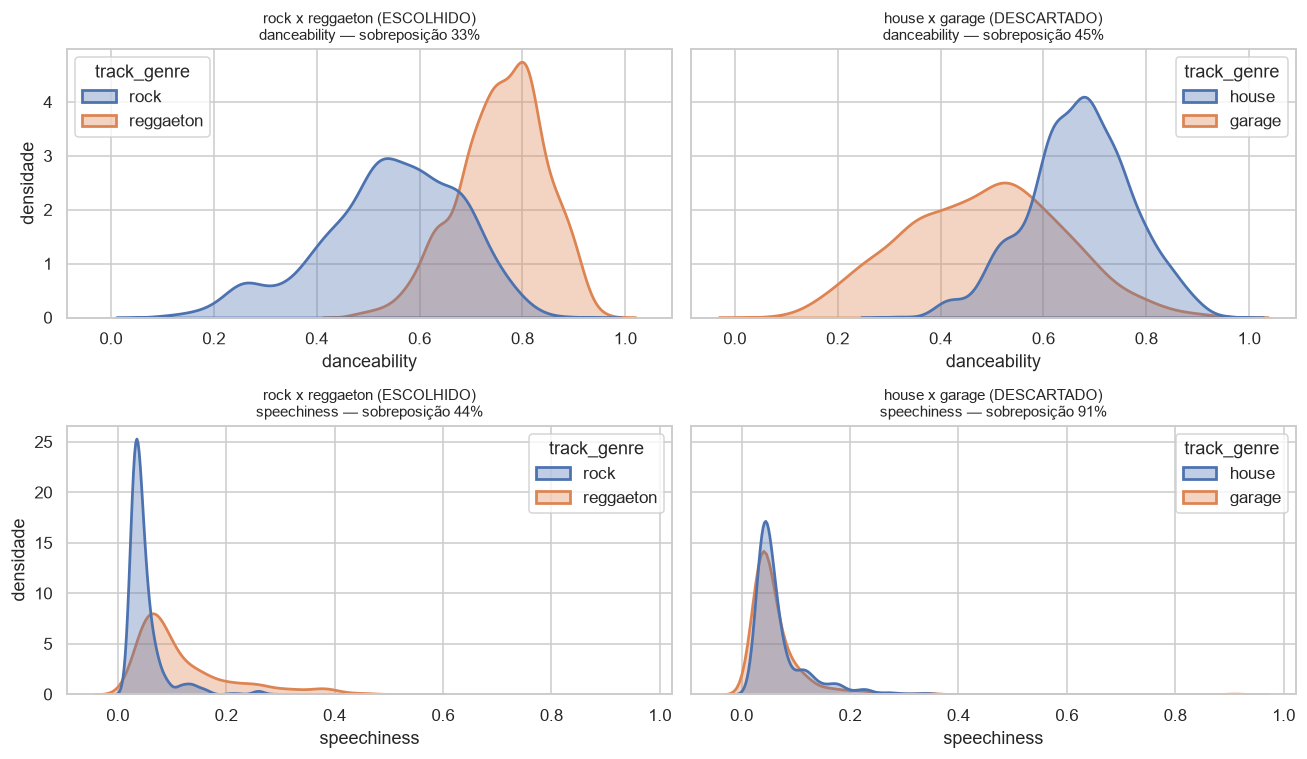

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex='row', sharey='row')

pares = [(['rock', 'reggaeton'], 'ESCOLHIDO'), (['house', 'garage'], 'DESCARTADO')]

for i, var in enumerate(['danceability', 'speechiness']):
    for j, (par, rotulo) in enumerate(pares):
        ax = axes[i, j]
        dados = df[df['track_genre'].isin(par)]
        sns.kdeplot(data=dados, x=var, hue='track_genre', hue_order=par,
                    fill=True, alpha=0.35, linewidth=1.8, common_norm=False, ax=ax)
        s = sobreposicao(dados.loc[dados.track_genre == par[0], var],
                         dados.loc[dados.track_genre == par[1], var])
        ax.set_title('%s x %s (%s)\n%s — sobreposição %.0f%%'
                     % (par[0], par[1], rotulo, var, s * 100), fontsize=10)
        ax.set_ylabel('densidade')

plt.tight_layout()
plt.show()

> **✅ Leitura:** em `danceability`, os dois pares até separam alguma coisa (33% contra 45% de
> sobreposição) — a vantagem do nosso par existe, mas é modesta. É em `speechiness` que a diferença
> fica gritante: **44% de sobreposição em rock × reggaeton contra 91% em house × garage**. Ali,
> `house` e `garage` são literalmente a mesma curva desenhada duas vezes.
>
> É exatamente isso que o ranking da seção 3.2 resume num número só: `house` × `garage` não tem uma
> segunda variável para contar história depois da primeira. Na média das nove variáveis, a
> sobreposição do par descartado é de **72%** (separação 0,279) contra **64%** do par escolhido
> (separação 0,364).

## 4. O perfil dos dois gêneros, em números

Antes dos gráficos, a tabela. Usamos **mediana** em vez de média porque várias dessas variáveis são
assimétricas (Aula 2), e a mediana não se deixa puxar por alguns extremos.

In [14]:
dupla = df[df['track_genre'].isin(PAR)].copy()

print('Faixas por gênero:'); print(dupla['track_genre'].value_counts())
print()
print('Faixas que estão nos DOIS gêneros ao mesmo tempo:',
      dupla.groupby('track_id')['track_genre'].nunique().gt(1).sum())

Faixas por gênero:
track_genre
reggaeton    1000
rock         1000
Name: count, dtype: int64[pyarrow]

Faixas que estão nos DOIS gêneros ao mesmo tempo: 0


In [15]:
perfil = (dupla.groupby('track_genre', observed=True)[AUDIO + ['duracao_min']]
          .agg(['median', 'std'])
          .T
          .round(3))
perfil.columns.name = None
perfil

reggaeton     rock
danceability     median      0.762    0.552
                 std         0.084    0.136
energy           median      0.745    0.703
                 std         0.110    0.192
loudness         median     -4.694   -6.127
                 std         1.764    2.648
speechiness      median      0.087    0.038
                 std         0.093    0.037
acousticness     median      0.121    0.096
                 std         0.152    0.247
instrumentalness median      0.000    0.000
                 std         0.021    0.090
valence          median      0.668    0.546
                 std         0.199    0.234
tempo            median    100.950  123.872
                 std        34.283   31.158
liveness         median      0.119    0.117
                 std         0.125    0.133
duracao_min      median      3.467    3.625
                 std         0.978    1.012

## 5. A resposta principal: as densidades lado a lado

Agora o gráfico que a pergunta-guia pede. Nove variáveis contínuas, mesma dupla de cores, uma curva
de densidade por gênero.

**Por que KDE e não histograma?** Porque queremos comparar **formato**, não quantidade. Dois
histogramas sobrepostos viram uma sopa visual, e o desenho muda conforme o número de caixinhas
(Aula 3). O eixo Y do KDE é **densidade**: a área embaixo de cada curva vale 1, então as duas curvas
são comparáveis mesmo que os grupos tivessem tamanhos diferentes — por isso `common_norm=False`.

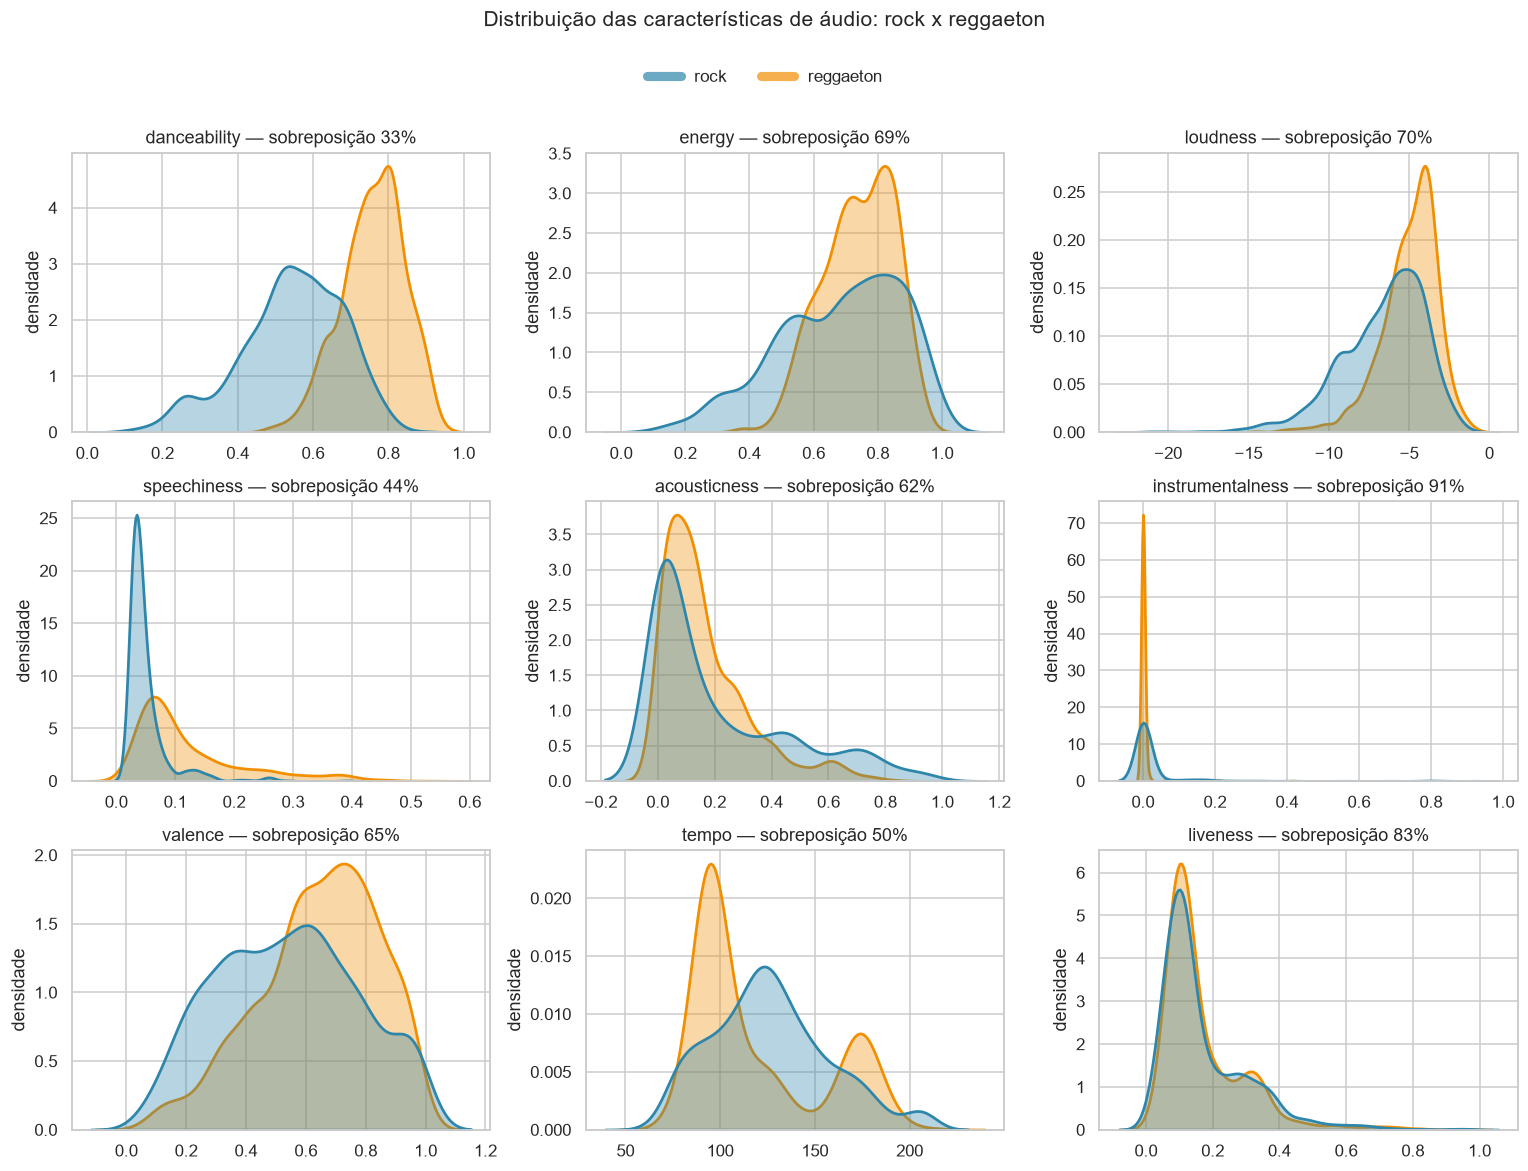

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, var in zip(axes, AUDIO):
    sns.kdeplot(data=dupla, x=var, hue='track_genre', hue_order=PAR, palette=CORES,
                fill=True, alpha=0.35, linewidth=1.8, common_norm=False, ax=ax, legend=False)
    s = sobreposicao(dupla.loc[dupla.track_genre == 'rock', var],
                     dupla.loc[dupla.track_genre == 'reggaeton', var])
    ax.set_title('%s — sobreposição %.0f%%' % (var, s * 100))
    ax.set_xlabel('')
    ax.set_ylabel('densidade')

# Uma legenda só, para a figura inteira.
alcas = [plt.Line2D([0], [0], color=CORES[g], lw=6, alpha=0.7, label=g) for g in PAR]
fig.legend(handles=alcas, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Distribuição das características de áudio: rock x reggaeton', y=1.06, fontsize=14)
plt.tight_layout()
plt.show()

### 5.1. Ordenando: quais variáveis realmente separam?

O painel acima mostra tudo, mas numa apresentação de 5 minutos não dá para discutir nove gráficos.
Vamos ordenar as variáveis pela separação e ficar com as que valem o tempo de tela.

Junto com a sobreposição, calculamos o **d de Cohen**, que mede a distância entre as *médias* em
desvios-padrão. As duas métricas juntas contam mais do que cada uma sozinha — e a diferença entre
elas é justamente o que torna o `tempo` interessante.

In [17]:
def d_cohen(x, y):
    # Distância entre as médias, medida em desvios-padrão.
    x, y = pd.Series(x).dropna(), pd.Series(y).dropna()
    s = np.sqrt(((len(x) - 1) * x.var() + (len(y) - 1) * y.var()) / (len(x) + len(y) - 2))
    return abs(x.mean() - y.mean()) / s


linhas = []
for var in AUDIO:
    x = dupla.loc[dupla.track_genre == 'rock', var]
    y = dupla.loc[dupla.track_genre == 'reggaeton', var]
    linhas.append({'variavel': var,
                   'mediana_rock': round(x.median(), 3),
                   'mediana_reggaeton': round(y.median(), 3),
                   'sobreposicao_%': round(sobreposicao(x, y) * 100, 1),
                   'separacao': round(1 - sobreposicao(x, y), 3),
                   'd_cohen': round(d_cohen(x, y), 2)})

tabela = pd.DataFrame(linhas).sort_values('separacao', ascending=False).reset_index(drop=True)
tabela

,variavel,mediana_rock,mediana_reggaeton,sobreposicao_%,separacao,d_cohen
0,danceability,0.552,0.762,32.8,0.672,1.90
1,speechiness,0.038,0.087,43.9,0.561,1.01
2,tempo,123.872,100.950,50.0,0.500,0.23
3,acousticness,0.096,0.121,61.5,0.385,0.22
4,valence,0.546,0.668,65.3,0.347,0.48
5,energy,0.703,0.745,68.6,0.314,0.38
6,loudness,-6.127,-4.694,69.8,0.302,0.75
7,liveness,0.117,0.119,82.9,0.171,0.02
8,instrumentalness,0.000,0.000,90.7,0.093,0.28


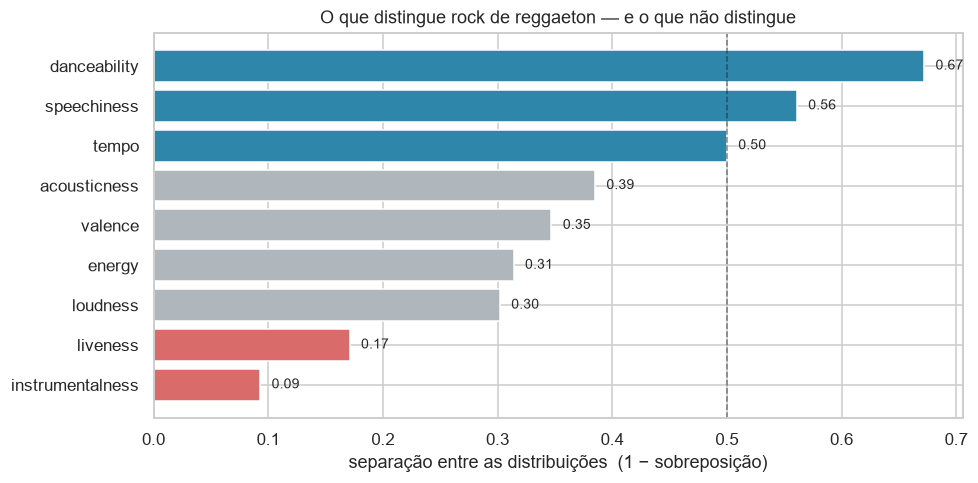

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
cores_barra = ['#2E86AB' if s >= 0.5 else '#B0B7BC' if s >= 0.3 else '#D96B6B'
               for s in tabela['separacao']]
ax.barh(tabela['variavel'], tabela['separacao'], color=cores_barra)
ax.invert_yaxis()
ax.set_xlabel('separação entre as distribuições  (1 − sobreposição)')
ax.set_title('O que distingue rock de reggaeton — e o que não distingue')
ax.axvline(0.5, color='k', ls='--', lw=1, alpha=0.5)

for y, v in enumerate(tabela['separacao']):
    ax.text(v + 0.01, y, '%.2f' % v, va='center', fontsize=9)

plt.tight_layout()
plt.show()

> **✅ Resposta 2 — três variáveis carregam a diferença:**
>
> | | sobreposição | d de Cohen | leitura |
> |---|---|---|---|
> | **`danceability`** | 33% | **1,90** | a mais forte, de longe. Reggaeton 0,76 × rock 0,55 |
> | **`speechiness`** | 44% | 1,01 | reggaeton tem mais que o dobro (0,087 × 0,038) |
> | **`tempo`** | 50% | **0,23** | separa pelo **formato**, não pelo centro — ver 6.3 |
>
> `loudness` aparece em seguida (d = 0,75): reggaeton é masterizado mais alto (−4,7 dB × −6,1 dB), o
> que é característico de produção eletrônica feita para tocar em festa e em fone de celular.

## 6. Zoom nas três que mais separam

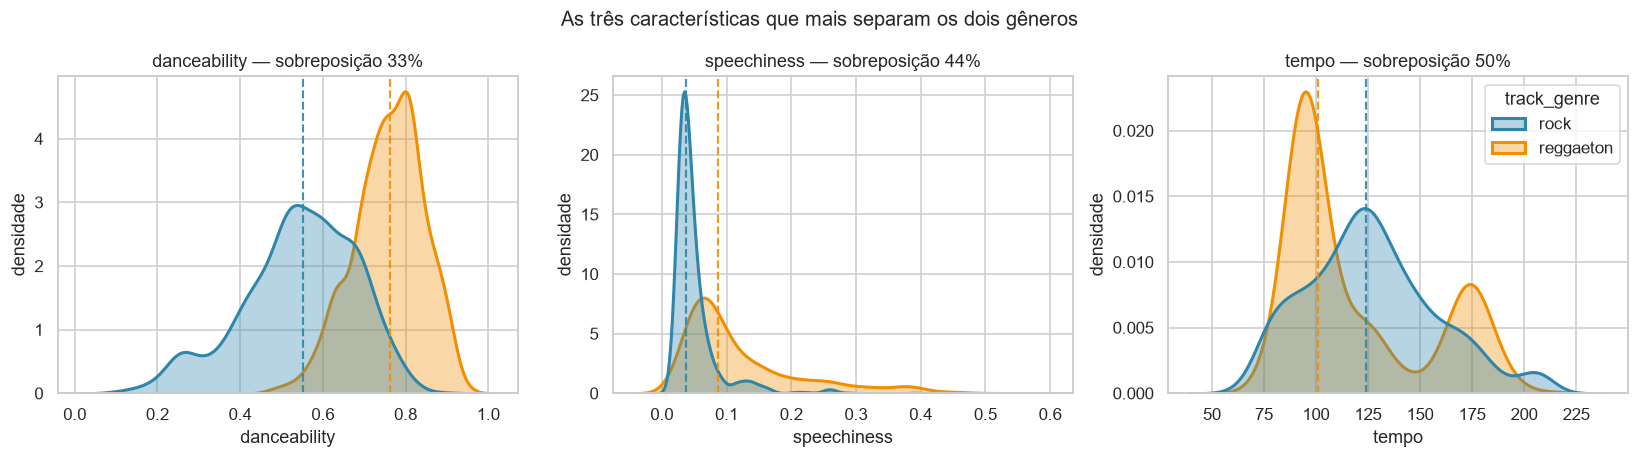

In [19]:
tres = ['danceability', 'speechiness', 'tempo']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for ax, var in zip(axes, tres):
    sns.kdeplot(data=dupla, x=var, hue='track_genre', hue_order=PAR, palette=CORES,
                fill=True, alpha=0.35, linewidth=2, common_norm=False, ax=ax,
                legend=(var == 'tempo'))
    # Linha tracejada na mediana de cada gênero, para ancorar a leitura.
    for g in PAR:
        ax.axvline(dupla.loc[dupla.track_genre == g, var].median(),
                   color=CORES[g], ls='--', lw=1.4, alpha=0.9)
    s = sobreposicao(dupla.loc[dupla.track_genre == 'rock', var],
                     dupla.loc[dupla.track_genre == 'reggaeton', var])
    ax.set_title('%s — sobreposição %.0f%%' % (var, s * 100))
    ax.set_ylabel('densidade')

fig.suptitle('As três características que mais separam os dois gêneros', fontsize=13)
plt.tight_layout()
plt.show()

### 6.1. `danceability` — a divisória mais limpa

A distância entre as médias é de **1,9 desvio-padrão**, o maior valor da tabela. Faz sentido
musicalmente: o algoritmo do Spotify pontua regularidade rítmica e batida forte e estável. O
*dembow* do reggaeton é uma célula rítmica programada que se repete a faixa inteira; o rock varia de
balada a andamento livre, com bateria tocada por gente.

O mais importante para a apresentação: **a curva do reggaeton é estreita e a do rock é larga**. Não
é só que o reggaeton dança mais — é que o reggaeton é muito mais *uniforme* no que faz.

In [20]:
# O quanto essa única variável, sozinha, já separa os dois gêneros?
for corte in [0.60, 0.65, 0.68, 0.70]:
    acerto = ((dupla.loc[dupla.track_genre == 'reggaeton', 'danceability'] > corte).sum() +
              (dupla.loc[dupla.track_genre == 'rock', 'danceability'] <= corte).sum()) / len(dupla)
    print('Regra "danceability > %.2f  =>  reggaeton":  acerta %.1f%% das 2.000 faixas'
          % (corte, acerto * 100))

# E somando a segunda variável mais separadora?
acerto2 = (((dupla.track_genre == 'reggaeton') ==
            ((dupla.danceability > 0.62) & (dupla.speechiness > 0.035))).mean())
print()
print('Regra "danceability > 0,62 E speechiness > 0,035  =>  reggaeton":  acerta %.1f%%'
      % (acerto2 * 100))

Regra "danceability > 0.60  =>  reggaeton":  acerta 78.6% das 2.000 faixas
Regra "danceability > 0.65  =>  reggaeton":  acerta 81.8% das 2.000 faixas
Regra "danceability > 0.68  =>  reggaeton":  acerta 83.2% das 2.000 faixas
Regra "danceability > 0.70  =>  reggaeton":  acerta 83.0% das 2.000 faixas

Regra "danceability > 0,62 E speechiness > 0,035  =>  reggaeton":  acerta 87.2%


> **✅ Leitura:** uma regra de uma linha — *"se `danceability` > 0,68, chute reggaeton"* — acerta
> **83% das 2.000 faixas**. Somando `speechiness`, sobe para **87%**. É a forma mais direta de
> mostrar que a separação vista no KDE não é impressão visual.

### 6.2. `speechiness` — o vocal em primeiro plano

Reggaeton tem mediana **0,087** contra **0,038** do rock: mais que o dobro. A variável mede o quanto
a faixa se parece com palavra falada, e o reggaeton fica na fronteira entre canto e rap, com o vocal
bem à frente na mixagem. No rock, a voz disputa espaço com guitarra e bateria.

Repare que a curva do rock é um pico **colado no zero**: é uma variável com limite natural em 0, e o
KDE espalha um pouco de densidade para além dele (Aula 3). Vale citar isso na apresentação como
cuidado de leitura — a área à esquerda do zero não existe.

### 6.3. `tempo` — o caso mais interessante do trabalho

Aqui as duas métricas **discordam**, e é aí que mora a análise:

- sobreposição **50%** → separação alta, entre as três maiores;
- d de Cohen **0,23** → distância entre as médias quase nula.

Como as duas coisas podem ser verdade ao mesmo tempo? Porque **a diferença não está no centro, está
no formato**. Um teste que só comparasse médias diria "tempo não distingue nada" e passaria reto.

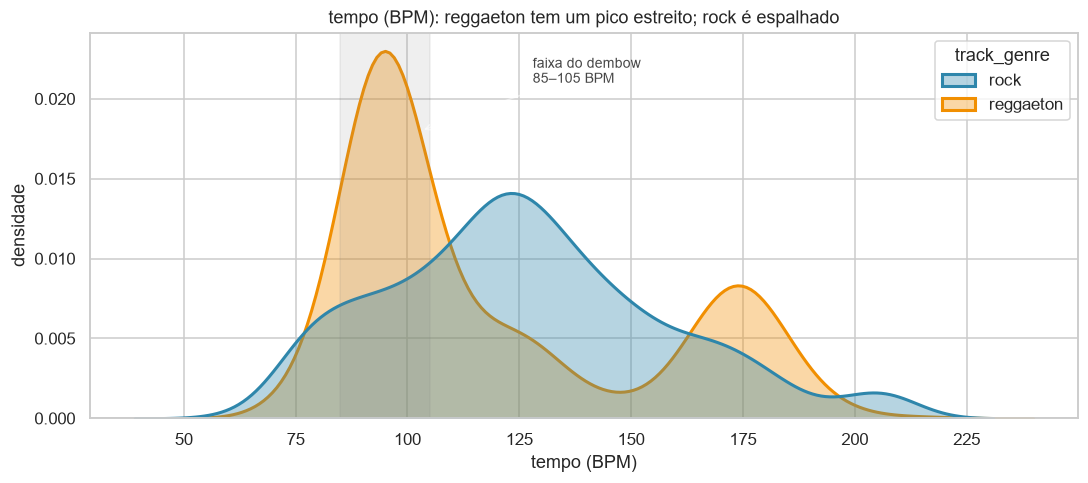

Faixas entre 85 e 105 BPM:
  rock        15.3%   (média 126 BPM, mediana 124 BPM)
  reggaeton   51.0%   (média 119 BPM, mediana 101 BPM)
Faixas entre 165 e 185 BPM:
  rock         9.3%   (média 126 BPM, mediana 124 BPM)
  reggaeton   19.0%   (média 119 BPM, mediana 101 BPM)


In [21]:
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.kdeplot(data=dupla, x='tempo', hue='track_genre', hue_order=PAR, palette=CORES,
            fill=True, alpha=0.35, linewidth=2, common_norm=False, ax=ax)
ax.axvspan(85, 105, color='gray', alpha=0.12)
ax.annotate('faixa do dembow\n85–105 BPM', xy=(103, 0.018), xytext=(128, 0.021),
            fontsize=9, alpha=0.85, ha='left',
            arrowprops=dict(arrowstyle='->', alpha=0.5))
ax.set_title('tempo (BPM): reggaeton tem um pico estreito; rock é espalhado')
ax.set_xlabel('tempo (BPM)')
ax.set_ylabel('densidade')
plt.tight_layout()
plt.show()

for faixa in [(85, 105), (165, 185)]:
    print('Faixas entre %d e %d BPM:' % faixa)
    for g in PAR:
        s = dupla.loc[dupla.track_genre == g, 'tempo']
        print('  %-10s %5.1f%%   (média %.0f BPM, mediana %.0f BPM)'
              % (g, s.between(*faixa).mean() * 100, s.mean(), s.median()))

> **✅ Leitura:** **51% do reggaeton** cabe na janela de 85–105 BPM, contra **15% do rock**. O
> reggaeton tem um pico altíssimo em torno de 95 BPM — o andamento do *dembow* — e um segundo grupo
> em torno de **175 BPM** (19% das faixas, contra 9% do rock), que é **o mesmo ritmo contado em
> dobro** pelo detector do Spotify: 95 × 2 ≈ 190. Ou seja, os dois picos do reggaeton são, na
> prática, o mesmo andamento.
>
> As duas médias ficam parecidas (119 × 126 BPM) justamente por causa disso: a média de uma
> distribuição com dois picos cai no vale entre eles, entre 120 e 140 BPM, onde o reggaeton quase
> não tem música. **A média aponta para o lugar mais vazio da distribuição.**
>
> **Esse é o argumento central a favor do gráfico de densidade:** a média escondeu o padrão, e a
> forma da curva o entregou de imediato.

## 7. E o que **não** diferencia os dois gêneros?

A pergunta 3 do enunciado é tão importante quanto a 2 — e costuma ser a mais esquecida. Duas
variáveis não servem para nada aqui, por motivos **diferentes**.

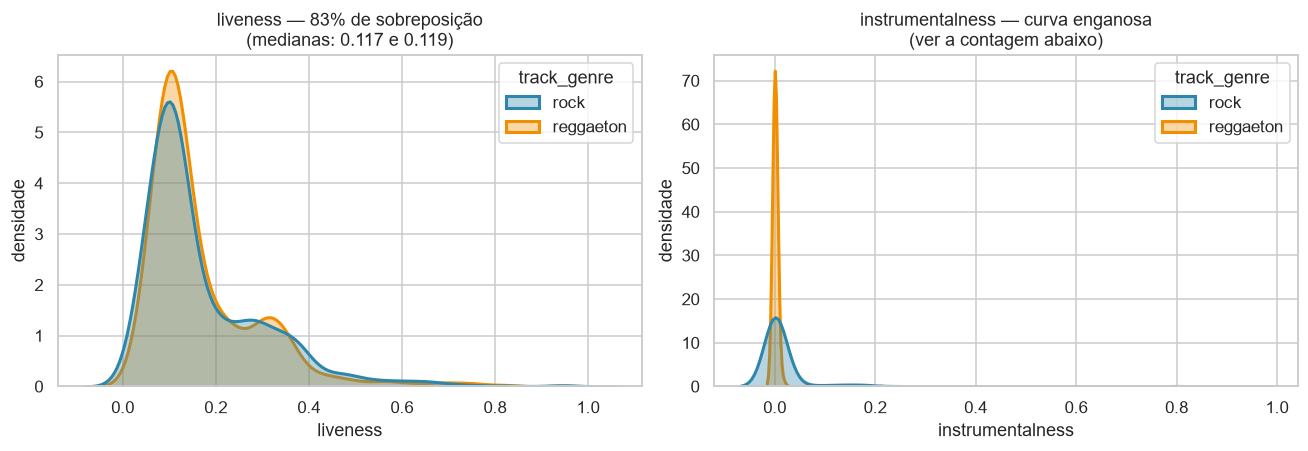

instrumentalness — o que realmente existe na base:
  rock       exatamente 0: 47.3%  |  abaixo de 0,01: 86.6%  |  acima de 0,5: 1.0%
  reggaeton  exatamente 0: 49.1%  |  abaixo de 0,01: 96.5%  |  acima de 0,5: 0.0%


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# liveness: sobreposição quase total, mas é uma variável bem-comportada.
sns.kdeplot(data=dupla, x='liveness', hue='track_genre', hue_order=PAR, palette=CORES,
            fill=True, alpha=0.35, linewidth=2, common_norm=False, ax=axes[0])
axes[0].set_title('liveness — 83%% de sobreposição\n(medianas: %.3f e %.3f)'
                  % (dupla.loc[dupla.track_genre == 'rock', 'liveness'].median(),
                     dupla.loc[dupla.track_genre == 'reggaeton', 'liveness'].median()))
axes[0].set_ylabel('densidade')

# instrumentalness: aqui o KDE está MENTINDO, e é por isso que ele está no notebook.
sns.kdeplot(data=dupla, x='instrumentalness', hue='track_genre', hue_order=PAR, palette=CORES,
            fill=True, alpha=0.35, linewidth=2, common_norm=False, ax=axes[1])
axes[1].set_title('instrumentalness — curva enganosa\n(ver a contagem abaixo)')
axes[1].set_ylabel('densidade')

plt.tight_layout()
plt.show()

print('instrumentalness — o que realmente existe na base:')
for g in PAR:
    s = dupla.loc[dupla.track_genre == g, 'instrumentalness']
    print('  %-10s exatamente 0: %.1f%%  |  abaixo de 0,01: %.1f%%  |  acima de 0,5: %.1f%%'
          % (g, (s == 0).mean() * 100, (s < 0.01).mean() * 100, (s > 0.5).mean() * 100))

> **✅ Resposta 3 — duas variáveis não ajudam, por motivos opostos:**
>
> **`liveness` (83% de sobreposição)** — o caso honesto. As medianas são 0,117 e 0,119, e as curvas
> são praticamente a mesma. Faz sentido: a variável detecta **plateia na gravação**, e as duas
> bases são majoritariamente de faixas de estúdio. Um rock ao vivo e um reggaeton ao vivo têm o
> mesmo indício de público. A variável mede formato de gravação, não gênero.
>
> **`instrumentalness` (91% de sobreposição)** — o caso em que **o gráfico não deveria ter sido
> feito**. Cerca de metade das faixas vale exatamente 0 e mais de 86% ficam abaixo de 0,01: não é
> uma variável contínua nesse recorte, é quase uma binária "tem vocal / não tem". O KDE desenha uma
> curva suave sobre um monte de zeros e sugere uma distribuição que não existe — exatamente o erro
> que a Aula 3 chama de *KDE de variável discreta*. A leitura correta é a contagem impressa acima,
> não a curva. Os dois gêneros são cantados; era esperado que não houvesse diferença.

## 8. A popularidade muda entre os dois gêneros?

Esta é a pergunta 4 — e é onde a limpeza da seção 2 decide o resultado.

In [23]:
# Primeiro, a leitura INGÊNUA: usando a coluna crua, com os zeros dentro.
print('--- Com os zeros tratados como popularidade real (ERRADO) ---')
print(dupla.groupby('track_genre', observed=True)['popularity']
      .agg(['median', 'mean']).round(1).to_string())
print()
print('--- Quantos desses zeros existem ---')
for g in PAR:
    s = dupla.loc[dupla.track_genre == g, 'popularity']
    print('  %-10s %.1f%% das faixas têm popularity = 0' % (g, (s == 0).mean() * 100))

--- Com os zeros tratados como popularidade real (ERRADO) ---
             median  mean
track_genre              
reggaeton       2.0  23.9
rock            0.0  19.0

--- Quantos desses zeros existem ---
  rock       52.5% das faixas têm popularity = 0
  reggaeton  36.2% das faixas têm popularity = 0


In [24]:
# Agora com a coluna limpa, em que 0 virou NaN ('não medido').
print('--- Com os zeros tratados como ausência de medida (CORRETO) ---')
print(dupla.groupby('track_genre', observed=True)['popularidade']
      .agg(['count', 'median', 'mean']).round(1).to_string())

--- Com os zeros tratados como ausência de medida (CORRETO) ---
             count  median  mean
track_genre                     
reggaeton      638    41.0  37.4
rock           475    47.0  40.0


> **⚠️ A conclusão se inverte.**
>
> | | mediana com zeros | mediana sem zeros |
> |---|---|---|
> | rock | **0** | **47** |
> | reggaeton | **2** | **41** |
>
> Na leitura ingênua, reggaeton pareceria mais popular que rock. Depois de tratar os zeros como o
> que eles são — **52,5% das faixas de rock simplesmente não tiveram a popularidade medida** — é o
> rock que fica à frente, com mediana 47 contra 41.
>
> **A resposta dependeu inteiramente de uma decisão de limpeza**, não do gráfico. Mas ainda não
> acabou: o gráfico abaixo mostra que nem essa segunda mediana é confiável.

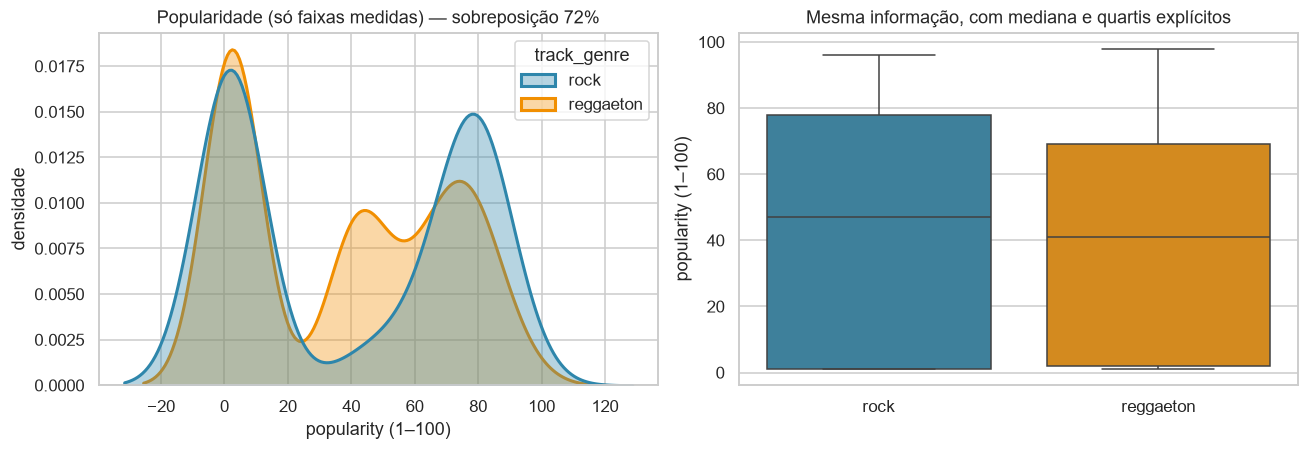

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.kdeplot(data=dupla, x='popularidade', hue='track_genre', hue_order=PAR, palette=CORES,
            fill=True, alpha=0.35, linewidth=2, common_norm=False, ax=axes[0])
axes[0].set_title('Popularidade (só faixas medidas) — sobreposição %.0f%%'
                  % (sobreposicao(dupla.loc[dupla.track_genre == 'rock', 'popularidade'],
                                  dupla.loc[dupla.track_genre == 'reggaeton', 'popularidade']) * 100))
axes[0].set_xlabel('popularity (1–100)')
axes[0].set_ylabel('densidade')

sns.boxplot(data=dupla, x='track_genre', y='popularidade', hue='track_genre',
            order=PAR, hue_order=PAR, palette=CORES, legend=False, ax=axes[1])
axes[1].set_title('Mesma informação, com mediana e quartis explícitos')
axes[1].set_xlabel('')
axes[1].set_ylabel('popularity (1–100)')

plt.tight_layout()
plt.show()

> **⚠️ De novo o mesmo problema do `tempo`.** A curva da esquerda tem **dois picos** e um vale largo
> no meio — e a mediana de 47 cai bem na beirada do vale. Antes de comparar medianas, precisamos
> medir esse buraco.

In [26]:
# A popularidade, depois de tirar os zeros, é mesmo uma distribuição só?
for g in PAR:
    s = dupla.loc[dupla.track_genre == g, 'popularidade'].dropna()
    print('%-10s (n = %d)' % (g, len(s)))
    print('   grupo BAIXO (1 a 10):   %5.1f%%' % ((s <= 10).mean() * 100))
    print('   VALE       (11 a 39):   %5.1f%%   <-- praticamente ninguém' % (s.between(11, 39).mean() * 100))
    print('   grupo ALTO (40 ou +):   %5.1f%%   | mediana dentro do grupo alto: %.0f'
          % ((s >= 40).mean() * 100, s[s >= 40].median()))
    print()

rock       (n = 475)
   grupo BAIXO (1 a 10):    47.4%
   VALE       (11 a 39):     0.4%   <-- praticamente ninguém
   grupo ALTO (40 ou +):    52.2%   | mediana dentro do grupo alto: 77

reggaeton  (n = 638)
   grupo BAIXO (1 a 10):    41.7%
   VALE       (11 a 39):     4.5%   <-- praticamente ninguém
   grupo ALTO (40 ou +):    53.8%   | mediana dentro do grupo alto: 68



> **✅ Leitura:** a popularidade nesta base é quase **binária**. No rock, só **0,4%** das faixas
> medidas ficam entre 11 e 39 — praticamente não existe faixa "mais ou menos popular". A mediana de
> 47 não descreve nenhuma faixa típica: ela cai no vazio entre os dois grupos. Só **1,9%** do rock
> tem popularidade entre 41 e 47.
>
> A comparação honesta é feita em duas partes:
>
> | | chega ao grupo alto | mediana **dentro** do grupo alto |
> |---|---|---|
> | rock | **52,2%** | **77** |
> | reggaeton | **53,8%** | **68** |
>
> Ou seja: **a proporção de faixas que "estouram" é praticamente igual nos dois gêneros** (52% × 54%).
> A diferença está em *quanto* estouram — entre as faixas populares, o rock chega mais alto
> (mediana 77 contra 68). A mediana geral de 47 × 41 misturava as duas coisas e não dizia nenhuma
> das duas.

In [27]:
# A popularidade tem relação com as características de áudio DENTRO de cada gênero?
corr = (dupla.dropna(subset=['popularidade'])
        .groupby('track_genre', observed=True)[AUDIO + ['popularidade']]
        .corr()['popularidade']
        .drop('popularidade', level=1)
        .unstack()
        .T
        .round(3))
corr.columns.name = None
print('Correlação de cada variável de áudio com a popularidade, dentro de cada gênero:')
corr

Correlação de cada variável de áudio com a popularidade, dentro de cada gênero:


,reggaeton,rock
danceability,0.045,0.076
energy,-0.070,-0.157
loudness,-0.053,-0.116
speechiness,-0.074,-0.022
acousticness,0.010,0.026
instrumentalness,0.036,0.001
valence,-0.035,-0.178
tempo,-0.040,-0.161
liveness,-0.024,-0.026


> **✅ Resposta 4 — quase não difere, e o áudio não explica o pouco que difere.**
>
> - **A chance de uma faixa "estourar" é igual nos dois gêneros:** 52,2% do rock e 53,8% do
>   reggaeton chegam ao grupo alto. Entre as que chegam, o rock vai um pouco mais longe
>   (mediana 77 × 68).
> - As distribuições se sobrepõem em **72%**: são duas nuvens com o mesmo formato de dois picos.
> - Dentro de cada gênero, **nenhuma característica de áudio passa de 0,18 de correlação com a
>   popularidade** (o recorde é `valence` no rock, −0,178) e quase todas ficam abaixo de 0,10. Ou
>   seja: subir a `danceability` de uma faixa de rock não a torna mais popular.
> - Isso é coerente com o que a variável mede: `popularity` depende de execuções recentes, playlists
>   editoriais, tamanho do artista e catálogo disponível na região. **É uma métrica de mercado, não
>   uma propriedade do som.**
>
> A conclusão prática: as características de áudio descrevem muito bem **o que o gênero é** (87% de
> acerto com duas variáveis), e quase nada sobre **o quanto ele é ouvido**.

### 8.1. Dois contrastes rápidos que reforçam a história

Nem tudo que separa os gêneros é contínuo. Duas variáveis categóricas fecham o retrato.

In [28]:
print('--- Conteúdo explícito (%) ---')
print((pd.crosstab(dupla['track_genre'], dupla['explicit'], normalize='index') * 100).round(1))
print()
print('--- Modo: 0 = menor, 1 = maior (%) ---')
print((pd.crosstab(dupla['track_genre'], dupla['mode'], normalize='index') * 100).round(1))

--- Conteúdo explícito (%) ---
explicit     False  True 
track_genre              
reggaeton     78.8   21.2
rock          95.7    4.3

--- Modo: 0 = menor, 1 = maior (%) ---
mode            0     1
track_genre            
reggaeton    48.9  51.1
rock         27.9  72.1


> **✅ Leitura:** **21% do reggaeton é explícito, contra 4% do rock** — uma diferença de cinco vezes,
> e a maior separação de todo o trabalho fora da `danceability`. E o rock é **72% em modo maior**,
> contra 51% do reggaeton, quase uma moeda. Curioso: o gênero com `valence` mais baixa (rock, 0,55)
> é o que mais usa tom maior. Tom maior e "soar alegre" não são a mesma coisa.

## 9. Conclusões

**Resposta à pergunta-guia:** entre rock e reggaeton, as características de áudio diferem de forma
clara, mas **concentrada em poucas variáveis** — e o gráfico de densidade foi o que permitiu ver
*como* elas diferem, não só *se* diferem.

1. **`danceability` é a divisória** (sobreposição 33%, d = 1,90). Reggaeton mediana 0,76 × rock 0,55.
   Sozinha, essa variável classifica 83% das faixas; com `speechiness`, 87%.
2. **`speechiness` confirma** (44%): o vocal em primeiro plano do reggaeton tem mais que o dobro do
   valor do rock.
3. **`tempo` separa pelo formato, não pela média.** 51% do reggaeton está entre 85 e 105 BPM contra
   15% do rock, mas as médias são quase idênticas (119 × 126 BPM). **Só o KDE mostra isso** — um
   teste de médias concluiria, erradamente, que o andamento não distingue nada.
4. **`liveness` não diferencia** (83% de sobreposição): ela mede se há plateia na gravação, e os dois
   gêneros são de estúdio. **`instrumentalness` também não**, mas por outro motivo: metade dos
   valores é exatamente 0, então o KDE desenha uma curva onde só existem dois estados.
5. **Popularidade: a estatística resumo enganou duas vezes.** Com os zeros dentro, reggaeton
   pareceria à frente (mediana 2 × 0); tratando os zeros como não medidos, o rock viraria (47 × 41).
   Mas a distribuição é quase **binária** — só 0,4% do rock fica entre 11 e 39 — e essa mediana cai
   no vazio. Medido direito: **a proporção de faixas que estouram é igual (52% × 54%)** e a
   diferença está só na altura do pico (77 × 68). E **nenhuma variável de áudio correlaciona mais
   que 0,18 com a popularidade** dentro de cada gênero.

**O fio condutor do trabalho:** em três momentos diferentes — `tempo`, `instrumentalness` e
`popularity` — uma média ou mediana apontou para um valor onde quase não existe música. Em todos
eles foi a **forma da distribuição** que corrigiu a leitura. É exatamente para isso que serve o
gráfico de densidade.

**O limite honesto desta análise:** são 1.000 faixas por gênero de uma amostra do Spotify, com
rótulo de gênero atribuído por algoritmo. O ranking da seção 3 mostrou, inclusive, pares de gêneros
com separação 0,00 (`singer-songwriter` × `songwriter`) — ou seja, o próprio rótulo tem redundância.
Nada aqui é sobre música em geral; é sobre como essa base descreve esses dois gêneros.

### 9.1. Roteiro da apresentação — 5 minutos

| Tempo | O que dizer | O que mostrar |
|---|---|---|
| **0:00–0:40** | A pergunta: dois gêneros, nove características, o que realmente os separa? Por que densidade e não média. | Slide de título |
| **0:40–1:20** | Escolha do par. Comparamos os **6.441** pares possíveis e ficamos com rock × reggaeton: distinto o bastante para ter história, não tão distinto a ponto de ser óbvio. | Tabela da seção 3.2 + gráfico 3.3 (par que separa × par que não separa) |
| **1:20–2:20** | O painel das nove densidades e o ranking de separação. Três variáveis carregam tudo. | Painel 3×3 (seção 5) e barras (5.1) |
| **2:20–3:10** | `danceability`: a divisória. Uma regra de uma linha acerta 83%; com `speechiness`, 87%. | Zoom da seção 6 |
| **3:10–3:50** | **O momento do trabalho:** `tempo`. Médias quase iguais, distribuições completamente diferentes. 51% × 15% na faixa do dembow. A média escondeu; a curva mostrou. | Gráfico do `tempo` (6.3) |
| **3:50–4:20** | O que **não** separa: `liveness` (83%) e `instrumentalness` (o KDE que mente). | Seção 7 |
| **4:20–5:00** | Popularidade: a conclusão virou duas vezes. 52,5% do rock sem medida; e a mediana cai num vale onde não há música. Medido direito, os dois estouram igual (52% × 54%). Áudio descreve o gênero, não o sucesso. | Tabelas da seção 8 |

**Fecho sugerido (uma frase):** *"Três vezes neste trabalho a média apontou para um valor onde não
existe música. Foi a forma da distribuição que corrigiu a leitura — é para isso que serve o KDE."*

**Se sobrar tempo:** 21% do reggaeton é explícito contra 4% do rock.
**Se faltar tempo:** cortar a seção 7 e ir direto para a popularidade.